In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.tools.eval_measures import rmse
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [2]:
df_advertising = pd.read_csv('C:/Users/Ashu/Downloads/advertising.csv')
df_advertising.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [3]:
df_advertising.shape

(200, 4)

In [4]:
df_advertising.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [5]:
df_advertising.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


In [6]:
df_advertising.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

<Axes: >

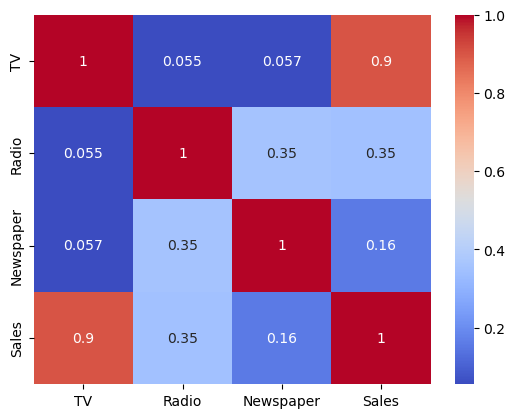

In [7]:
sns.heatmap(df_advertising.corr(), annot=True, cmap='coolwarm')

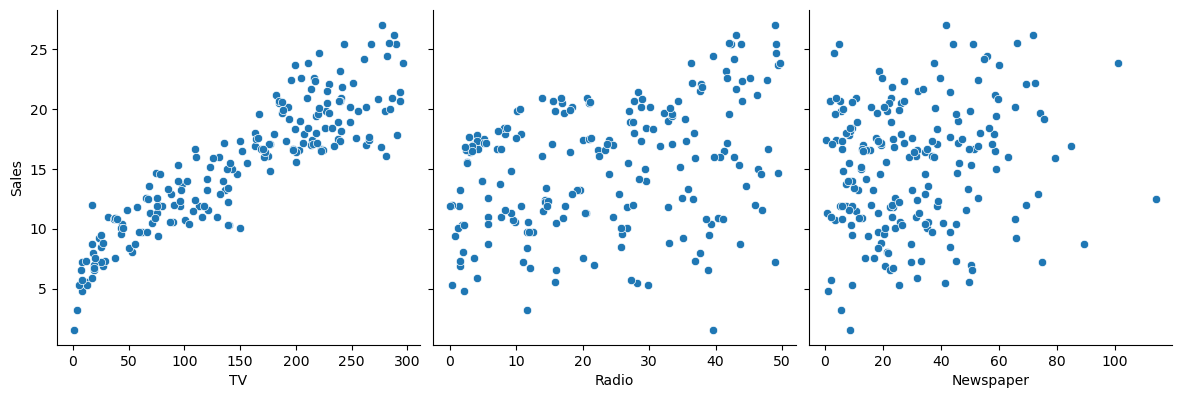

In [8]:
sns.pairplot(df_advertising, x_vars=['TV', 'Radio', 'Newspaper'], y_vars='Sales', height=4, aspect=1, kind='scatter')

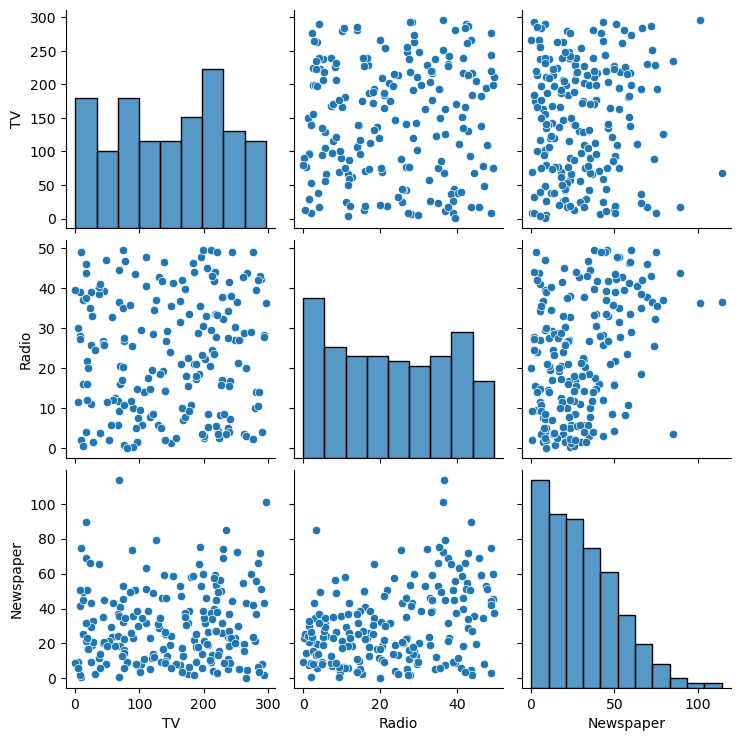

In [9]:
sns.pairplot(df_advertising[['TV', 'Radio', 'Newspaper']])

<Axes: >

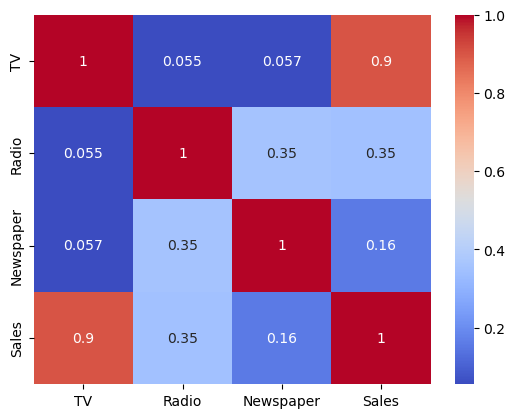

In [10]:
sns.heatmap(df_advertising.corr(), annot=True, cmap='coolwarm')

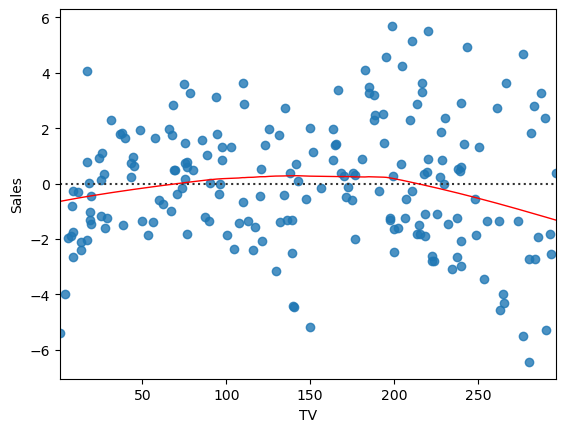

In [11]:
sns.residplot(x='TV', y='Sales', data=df_advertising, lowess=True, line_kws={'color': 'red', 'lw': 1})
plt.show()

In [12]:
Ststsmodels_model = smf.ols(formula='Sales ~ TV', data = df_advertising)
Ststsmodels_result = Ststsmodels_model.fit()

# print the coefficients
Ststsmodels_result.params

Intercept    6.974821
TV           0.055465
dtype: float64

In [13]:
X = df_advertising[['TV']]
y = df_advertising['Sales']
sklearn_model = LinearRegression()
SKLearn_result = sklearn_model.fit(X, y)
print(sklearn_model.intercept_)
print(sklearn_model.coef_)

6.9748214882298925
[0.05546477]


In [14]:
# y= c + m*x
# where c is the y-intercept and m is the slope
Sales = 6.9748214882298925 + 0.05546477 * 50
Sales * 1000

9748.059988229892

In [15]:
# STATSMODEL #
X_new = pd.DataFrame({'TV': [50]})
Sales = Ststsmodels_result.predict(X_new)    
Sales * 1000

0    9748.060012
dtype: float64

In [16]:
#SCITKIT-LEARN #
Sales = SKLearn_result.predict(np.array([[50]]))
Sales * 1000

array([9748.06001171])

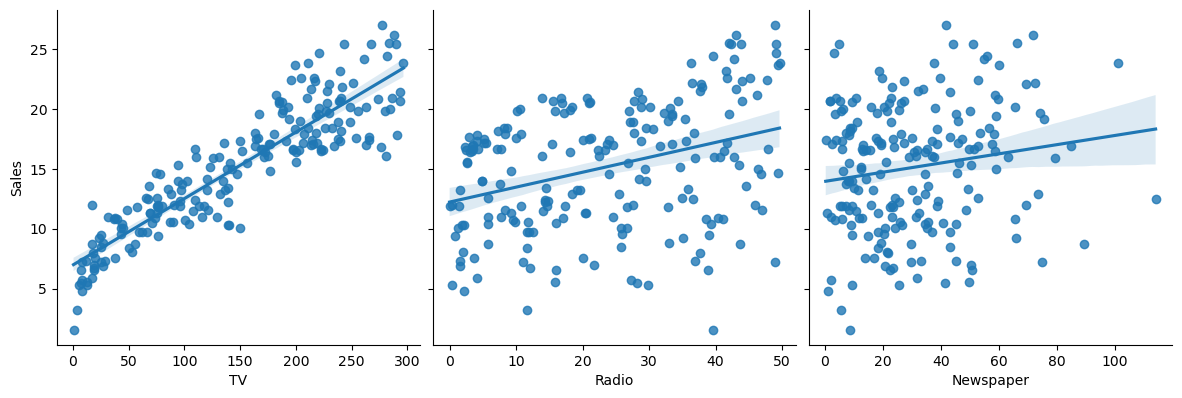

In [17]:
 ## Plotting the regression line
sns.pairplot(df_advertising, x_vars=['TV','Radio','Newspaper'], y_vars='Sales', height=4, aspect=1, kind='reg')
plt.show()

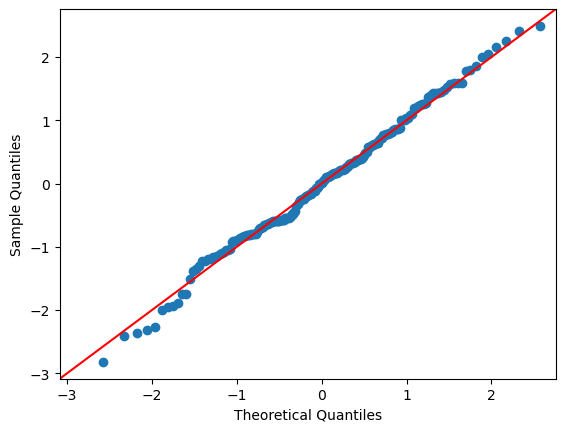

In [21]:
Ststsmodels_residual = Ststsmodels_result.resid
ax = sm.qqplot(Ststsmodels_residual , fit=True, line='45')
plt.show()

In [22]:
Ststsmodels_result.conf_int()

,0,1
Intercept,6.338740,7.610903
TV,0.051727,0.059203


In [24]:
Ststsmodels_result.pvalues

Intercept    5.027719e-54
TV           7.927912e-74
dtype: float64

In [27]:
Ststsmodels_result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.812
Model:                            OLS   Adj. R-squared:                  0.811
Method:                 Least Squares   F-statistic:                     856.2
Date:                Mon, 03 Aug 2026   Prob (F-statistic):           7.93e-74
Time:                        23:05:48   Log-Likelihood:                -448.99
No. Observations:                 200   AIC:                             902.0
Df Residuals:                     198   BIC:                             908.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      6.9748      0.323     21.624      0.000       6.339       7.611
TV             0.0555      0.002     29.260      0.000       0.052       0.059
==============================================================================
Omnibus:                        0.013   Durbin-Watson:                   2.029
Prob(Omnibus):                  0.993   Jarque-Bera (JB):                0.043
Skew:                          -0.018   Prob(JB):                        0.979
Kurtosis:                       2.938   Cond. No.                         338.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""